# Week 1 - Maryi Tatiana Palacios Giraldo

Bandit Environment

In [8]:
import numpy as np

class BanditEnv:
    def __init__(self, k=10):
        self.k = k
        self.q_true = np.random.normal(0, 1, k)  # true means
        self.optimal_action = np.argmax(self.q_true)

    def reset(self):
        return None  # no state

    def step(self, action):
        reward = np.random.normal(self.q_true[action], 1)
        return None, reward, False, {}

ε-greedy Agent

In [9]:
class EpsilonGreedyAgent:
    def __init__(self, k, epsilon):
        self.k = k
        self.epsilon = epsilon
        self.q_estimates = np.zeros(k)
        self.action_counts = np.zeros(k)

    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.k)
        return np.argmax(self.q_estimates)

    def update(self, action, reward):
        self.action_counts[action] += 1
        n = self.action_counts[action]
        self.q_estimates[action] += (reward - self.q_estimates[action]) / n

UCB Agent

In [10]:
class UCBAgent:
    def __init__(self, k, c):
        self.k = k
        self.c = c
        self.q_estimates = np.zeros(k)
        self.action_counts = np.zeros(k)
        self.total_steps = 0

    def select_action(self):
        self.total_steps += 1
        
        if 0 in self.action_counts:
            return np.argmin(self.action_counts)

        ucb_values = self.q_estimates + self.c * np.sqrt(
            np.log(self.total_steps) / self.action_counts
        )
        return np.argmax(ucb_values)

    def update(self, action, reward):
        self.action_counts[action] += 1
        n = self.action_counts[action]
        self.q_estimates[action] += (reward - self.q_estimates[action]) / n

experiment

In [16]:
def run_experiment(agent_class, param, runs=1000, steps=2000, k=10):
    rewards = np.zeros((runs, steps))
    optimal_actions = np.zeros((runs, steps))

    for run in range(runs):
        env = BanditEnv(k)
        agent = agent_class(k, param)

        for t in range(steps):
            action = agent.select_action()
            _, reward, _, _ = env.step(action)

            agent.update(action, reward)

            rewards[run, t] = reward
            optimal_actions[run, t] = (action == env.optimal_action)

    avg_rewards = rewards.mean(axis=0)
    optimal_action_pct = optimal_actions.mean(axis=0)

    return avg_rewards, optimal_action_pct

Run experiment(ε-greedy + UCB)

In [17]:
epsilons = [0.01, 0.1, 0.2]
ucb_cs = [1, 2, 5]

results = {}

# epsilon-greedy
for eps in epsilons:
    avg_r, opt = run_experiment(EpsilonGreedyAgent, eps)
    results[f"epsilon={eps}"] = (avg_r, opt)

# UCB
for c in ucb_cs:
    avg_r, opt = run_experiment(UCBAgent, c)
    results[f"ucb_c={c}"] = (avg_r, opt)

Visualizations

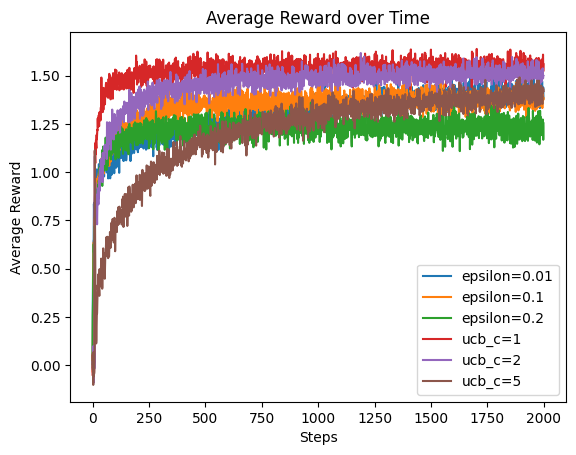

In [18]:
import matplotlib.pyplot as plt

# Average reward
plt.figure()
for label, (avg_r, _) in results.items():
    plt.plot(avg_r, label=label)

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward over Time")
plt.legend()
plt.show()

Figure 1: UCB achieves higher average reward over time compared to ε-greedy due to more efficient exploration. While ε-greedy continues random exploration, UCB focuses on uncertain actions, leading to faster convergence.

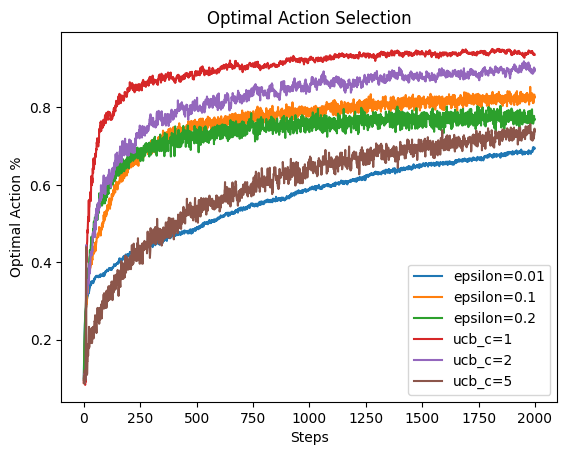

In [19]:
# Optimal action %
plt.figure()
for label, (_, opt) in results.items():
    plt.plot(opt, label=label)

plt.xlabel("Steps")
plt.ylabel("Optimal Action %")
plt.title("Optimal Action Selection")
plt.legend()
plt.show()

Figure 2: UCB reaches a higher percentage of optimal action selection more quickly, demonstrating its ability to identify the best action faster than ε-greedy methods.